# 4.1 Datetimes

:::{admonition} Lesson Content
:class: note, dropdown
- Dates
- Datetimes
- Timedeltas
:::

## Context
Dates and times are a common part of working with scientific data.  They are very common fields.  While dates and times are commonly represented as strings, you can also represent them using Python-specific objects that come with added functionality specific to dates and times.

## Python library `datetime`

The `datetime` library has three major components:
1. `date()` - for handling a date (Ex. 2021-06-28)
2. `datetime()` - for handling a specific time of a particular date (Ex. 2021-06-28 at 12:31pm)
3. `timedelta()` - for handling a length of time (Ex. 1 hour, 2 weeks, 3.5 years)

## Dates

In [1]:
from datetime import date

In [2]:
date(2017, 6, 30)

datetime.date(2017, 6, 30)

In [3]:
# assigning a date to a variable
birthday = date(2019, 9, 12)

### Why bother?
The dates are nice, but why put in the effort?  Your data by default probably uses a string, for example `2016-06-30`, so why not stick with that?

#### Reason 1
> If Python knows it's a date it can help you find errors.

In [4]:
date(2017, 6, 31)

ValueError: day is out of range for month

In [5]:
# Feb 29 exists during a leap year
date(2012, 2, 29)

datetime.date(2012, 2, 29)

In [6]:
# But not during other years!
date(2011, 2, 29)

ValueError: day is out of range for month

#### Reason 2
> Added organization through quick accessing of elements.

We'll talk about this more below.

### Accessing parts of a date

Once you have a date created you can easily pull out the piece you want.

In [7]:
campaign_start = date(2011, 5, 15)

In [8]:
campaign_start.month

5

In [9]:
# Monday is 0 and Sunday is 6
campaign_start.weekday()

6

:::{admonition} 📝 Check your understanding
:class: tip

Create a date object that represents your birthday.

:::

### Using `dates()` with other objects
You can do what you want with these objects, such as putting them in lists or dictionaries.

In [10]:
holidays = [date(2021, 1, 1), date(2021, 1, 18), date(2021, 11, 25)]
holidays_dict = {
    'New Years Day': date(2021, 1, 1),
    'MLK Day': date(2021, 1, 18),
    'Thanksgiving': date(2021, 11, 25),
}

In [11]:
holidays_dict['Thanksgiving']

datetime.date(2021, 11, 25)

### A comment on calendars

Turns out there are actually lots of different calendars that can be used to track time.  The one you are most likely familiar with is the Gregorian calendar (using years, months, and days).  Another common one that you will use is a Julian calendar, which starts on January 1st and counts the days one by one.

If you use model data you will also find more types of calendars, such as `365_day` (just ignores leap days) or `360_day` (every month has 30 days).

<img src="https://imgs.xkcd.com/comics/leap_smearing.png" width=350>


:::{admonition} 📝 Check your understanding
:class: tip

```
holidays_dict = {
    'New Years Day': date(2021, 1, 1),
    'MLK Day': date(2021, 1, 18),
    'Thanksgiving': date(2021, 11, 25),
}
```
What is the output of `holidays_dict['MLK Day'].day`?

:::

## Datetimes

### Creating `datetime()` objects manually

In [12]:
from datetime import datetime

In [13]:
# Created just like `date` objects
datetime(2021, 9, 21, 13, 45, 0)

datetime.datetime(2021, 9, 21, 13, 45)

We have the same ability as with `date()`s to access the different parts of the datetime object.  One place this could come in handy is if we need to narrow down our data by some aspect of the date.

In [14]:
example = datetime(2021, 9, 21, 13, 45, 0)
if example.hour >= 12 and example.hour <= 18:
    print('sample taken in the afternoon')

sample taken in the afternoon


### A comment on timezones

The `datetime` library also has the ability to keep track and convert timezones.  Timezones can cause a lot of chaos in the data world.  We aren't going to talk about them in depth but know that if you need to track timezones for whatever reason `datetime` can handle that.

## Creating `date()`s and `datetime()`s from strings

Thus far we have created our time objects by inputing the integer number of the year, month, etc.  Much more commonly, though, you aren't creating them from scratch, you are creating them from a string.  For that we have `strptime` and `strftime`.

| Syntax      | Description |
| :-----------: | :-----------: |
| `datetime.strptime()`      | Convert from string to datetime       |
| `DATETIME_OBJECT.strftime()`   | Convert from datetime to string       |

All of the following strings can be converted programatically into datetime objects:
* `'2019-01-29'`
* `'01-31-88'`
* `'September 12 7:00PM'`
* `'Apr 11 2001 13:00:00'`
* `'210 9:00'`
* And so many other combinations

The key part of converting from string to datetime and vice versa is that we need to tell the computer what is supposed to be looking for in the string.  For that we have labels, or directives, such as `%Y` or `%d`.  The place to consult for format strings is [strftime.org](https://strftime.org/).

### Some Examples

#### Example 1

In [15]:
date_string = '2019-01-29'

#### Example 2

In [16]:
date_string = 'Apr 11 2001 13:00:00'

#### Example 3

_Switching date formats_

In [17]:
start_date_string = '2016234'

In [18]:
# Goal: '2016-08-21 00:00:00'

:::{admonition} 📝 Check your understanding
:class: tip

What is the format string corresponding to the following datetime string?

`'8/30/2019 22:13:00'`, which shows the date August 30th 2019 at 10:13PM (military time).

:::

## `timedelta()` objects

While `date()`sand `datetime()`s represent a specific moment in time, `timedelta()`s represent a length of time, for example, one week, two hours, or 15 seconds.  They aren't connected to any particular moment, they just represent a set length of time.

In [19]:
from datetime import timedelta

In [20]:
# Representing 3 days
timedelta(days=3)

datetime.timedelta(days=3)

In [21]:
date.today() + timedelta(days=3)

datetime.date(2023, 8, 6)

In [22]:
# Negatives also work
date.today() + timedelta(days=-3)

datetime.date(2023, 7, 31)

When we combine `timedelta()`s and `datetime()`s what we get is the ability to really quickly determine how long there is between two things.

In [23]:
# Combine lengths of time
datetime.now() + timedelta(days=3, hours=1)

datetime.datetime(2023, 8, 6, 16, 3, 39, 209746)

In [24]:
# If you want to find the difference between two lengths of time
date.today() - date(2021, 11, 25)

datetime.timedelta(days=616)

:::{admonition} 📝 Check your understanding
:class: tip

How many days are there between today and Thanksgiving of this year (November 25th 2022)?

:::

## Code Summary

In [25]:
from datetime import datetime, date, timedelta

In [26]:
# Creating a single date
independence_day = date(2022, 7, 4)
# Creating a single datetime
flight_start = datetime(2021, 12, 17, 9, 28, 00)

# Inspecting dates/datetimes
print('independence day was on the day of week :', independence_day.weekday())  # 0 is Monday
print('flight month:', flight_start.month)

# Parsing strings
date_string = '2019-01-29'
dt = datetime.strptime(date_string, '%Y-%m-%d')
print("I'm a datetime object:", dt)

# Timedeltas
timedelta(days=7)
print('one week from today will be:', datetime.today()+timedelta(days=7))
print('this year started ', datetime.today() - datetime(2022, 1, 1), 'ago')


independence day was on the day of week : 0
flight month: 12
I'm a datetime object: 2019-01-29 00:00:00
one week from today will be: 2023-08-10 15:03:39.234559
this year started  579 days, 15:03:39.234617 ago


## Datetimes and `pandas`

Datetimes _really_ become powerful when you use them with the `pandas` library. Let's see an example of this in action with a dataset.

The dataset being using is Fluxtower data from the VCU Rice Rivers Center Fluxtower. The data can be accessed [here](https://ameriflux.lbl.gov/sites/siteinfo/US-RRC) ([https://ameriflux.lbl.gov/sites/siteinfo/US-RRC](https://ameriflux.lbl.gov/sites/siteinfo/US-RRC)).

First let's open the dataset with pandas

In [47]:
import pandas as pd

In [48]:
fluxtower = pd.read_csv('data/AMF_US-RRC_BASE_HH_2-5.csv', skiprows=2)

As always, let's check off our data exploration steps:
1. What variables are available in this dataset?
2. How is the dataset organized? What is the size?
3. Do there appear to be any nodata values in this dataset?
4. Do the variables appear to have reasonable values?
5. Make a simple plot of 1-2 variables

In [49]:
fluxtower

,TIMESTAMP_START,TIMESTAMP_END,CH4,CO2,FC,FCH4,H,H2O,MO_LENGTH,LE,...,WTD_1_1_1,WTD_2_1_1,WTD_PI_1,P_1_1_1,TS_PI_1,SW_IN_1_1_1,SWC_PI_1,NETRAD_1_1_1,PPFD_IN_1_1_1,RH_1_1_1
0,202201010000,202201010030,-9999.00,-9999.000,-9999.00000,-9999.000,-9999.0000,-9999.0000,-9999.00000,-9999.000,...,-9999.0,-9999.0,-9999.0,-9999.0,-9999.000000,-9999.000,-9999.000000,-9999.000,-9999.000,-9999.0000
1,202201010030,202201010100,-9999.00,-9999.000,-9999.00000,-9999.000,-9999.0000,-9999.0000,-9999.00000,-9999.000,...,-9999.0,-9999.0,-9999.0,-9999.0,-9999.000000,-9999.000,-9999.000000,-9999.000,-9999.000,-9999.0000
2,202201010100,202201010130,-9999.00,-9999.000,-9999.00000,-9999.000,-9999.0000,-9999.0000,-9999.00000,-9999.000,...,-9999.0,-9999.0,-9999.0,-9999.0,-9999.000000,-9999.000,-9999.000000,-9999.000,-9999.000,-9999.0000
3,202201010130,202201010200,-9999.00,-9999.000,-9999.00000,-9999.000,-9999.0000,-9999.0000,-9999.00000,-9999.000,...,-9999.0,-9999.0,-9999.0,-9999.0,-9999.000000,-9999.000,-9999.000000,-9999.000,-9999.000,-9999.0000
4,202201010200,202201010230,-9999.00,-9999.000,-9999.00000,-9999.000,-9999.0000,-9999.0000,-9999.00000,-9999.000,...,-9999.0,-9999.0,-9999.0,-9999.0,-9999.000000,-9999.000,-9999.000000,-9999.000,-9999.000,-9999.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48160,202409300800,202409300830,2067.19,418.459,9.46510,356.292,24.2034,24.8700,-29.67980,102.541,...,-9999.0,-9999.0,-9999.0,0.0,23.833333,160.333,63.686100,140.627,333.144,90.2877
48161,202409300830,202409300900,2038.25,412.303,16.13130,356.068,28.4025,24.9232,-7.58720,177.711,...,-9999.0,-9999.0,-9999.0,0.0,23.833333,209.732,63.668233,188.558,429.674,86.9003
48162,202409300900,202409300930,2036.33,409.203,9.18739,326.943,28.0833,24.8638,-9.40072,198.703,...,-9999.0,-9999.0,-9999.0,0.0,23.833333,222.259,63.668900,206.376,466.699,84.2807
48163,202409300930,202409301000,2051.15,410.137,15.29660,217.778,10.3241,25.2031,-286.52500,196.958,...,-9999.0,-9999.0,-9999.0,0.0,23.833333,150.553,63.678133,141.378,315.578,85.5835


In [65]:
# Look reasonable
fluxtower.max()

TIMESTAMP_START    2024-09-30 10:00:00
TIMESTAMP_END      2024-09-30 10:03:00
CH4                            5462.83
CO2                             864.19
FC                             99.9152
FCH4                       4084.780273
H                              758.098
H2O                          56.088799
MO_LENGTH                     120490.0
LE                         1492.359985
NEE_PI                      107.468033
PA_1_1_1                    104.464996
SC                           57.326199
SCH4                        181.220001
SH                             48.5709
SLE                         158.322998
TA_1_1_1                        39.902
TAU                           0.628498
U_SIGMA                        3.13384
USTAR                          1.21349
V_SIGMA                        3.17934
VPD_PI_1_1_1                 50.560001
W_SIGMA                       1.598771
WD_1_1_1                         360.0
WS_1_1_1                       7.16506
ZL                       

Looks like we have nans...

In [51]:
import numpy as np

In [52]:
fluxtower = fluxtower.replace(-9999, np.nan)

In [53]:
fluxtower.head()

,TIMESTAMP_START,TIMESTAMP_END,CH4,CO2,FC,FCH4,H,H2O,MO_LENGTH,LE,...,WTD_1_1_1,WTD_2_1_1,WTD_PI_1,P_1_1_1,TS_PI_1,SW_IN_1_1_1,SWC_PI_1,NETRAD_1_1_1,PPFD_IN_1_1_1,RH_1_1_1
0,202201010000,202201010030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,202201010030,202201010100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,202201010100,202201010130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,202201010130,202201010200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,202201010200,202201010230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

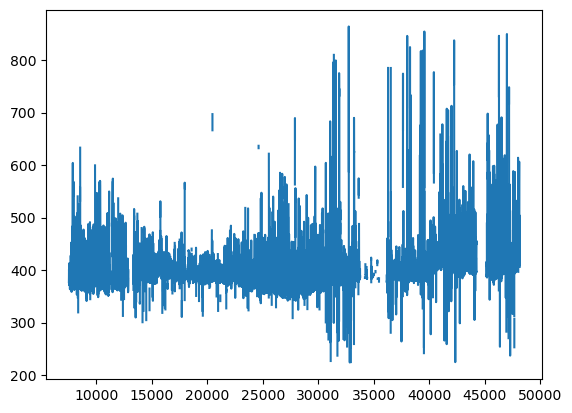

In [54]:
fluxtower['CO2'].plot()

Great. Our initial exploration showed us that this dataset is organized by time. It is a timeseries of carbon dioxide and methane, as well as related measurements.

### Converting a column to datetime

One of the built-in datetime features of pandas is `pd.to_datetime()` This is a function that can be used on a column of data to convert the column from a string to a datetime. It takes the argument `format`, which uses the same `%` symbology discussed above to convert the string.

In [55]:
pd.to_datetime(fluxtower['TIMESTAMP_START'], format='%Y%m%d%H%M%S')

0       2022-01-01 00:00:00
1       2022-01-01 00:03:00
2       2022-01-01 01:00:00
3       2022-01-01 01:03:00
4       2022-01-01 02:00:00
                ...        
48160   2024-09-30 08:00:00
48161   2024-09-30 08:03:00
48162   2024-09-30 09:00:00
48163   2024-09-30 09:03:00
48164   2024-09-30 10:00:00
Name: TIMESTAMP_START, Length: 48165, dtype: datetime64[ns]

Looks good! Let's do it to both the start time and stop time columns.

In [59]:
fluxtower['TIMESTAMP_START'] = pd.to_datetime(
    fluxtower['TIMESTAMP_START'], format='%Y%m%d%H%M%S')
fluxtower['TIMESTAMP_END'] = pd.to_datetime(
    fluxtower['TIMESTAMP_END'], format='%Y%m%d%H%M%S')

What has been gained? Well now that the column is a datetime any of the datetime attributes discussed above can be used using the `.dt.` accessor.

In [23]:
fluxtower['TIMESTAMP_START'].dt.hour

0         0
1         0
2         1
3         1
4         2
         ..
48160     8
48161     8
48162     9
48163     9
48164    10
Name: TIMESTAMP_START, Length: 48165, dtype: int32

In [64]:
fluxtower['TIMESTAMP_START'].dt.year

0        2022
1        2022
2        2022
3        2022
4        2022
         ... 
48160    2024
48161    2024
48162    2024
48163    2024
48164    2024
Name: TIMESTAMP_START, Length: 48165, dtype: int32

We could, for example, create a new column called "hour" on the end of our dataframe and use it to filter our data:

In [68]:
fluxtower['HOUR'] = fluxtower['TIMESTAMP_START'].dt.hour

In [69]:
fluxtower[fluxtower['HOUR'] == 8]

,TIMESTAMP_START,TIMESTAMP_END,CH4,CO2,FC,FCH4,H,H2O,MO_LENGTH,LE,...,WTD_2_1_1,WTD_PI_1,P_1_1_1,TS_PI_1,SW_IN_1_1_1,SWC_PI_1,NETRAD_1_1_1,PPFD_IN_1_1_1,RH_1_1_1,HOUR
16,2022-01-01 08:00:00,2022-01-01 08:03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
17,2022-01-01 08:03:00,2022-01-01 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
64,2022-01-02 08:00:00,2022-01-02 08:03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
65,2022-01-02 08:03:00,2022-01-02 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
112,2022-01-03 08:00:00,2022-01-03 08:03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48065,2024-09-28 08:03:00,2024-09-28 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
48112,2024-09-29 08:00:00,2024-09-29 08:03:00,2465.15,509.790,-12.3026,74.8341,34.3559,23.9035,-1.42501,57.5317,...,NaN,NaN,0.0,23.434433,264.278,63.661100,268.164,504.793,88.1168,8
48113,2024-09-29 08:03:00,2024-09-29 09:00:00,NaN,479.043,28.6803,NaN,17.4133,24.3529,-26.57900,139.8090,...,NaN,NaN,0.0,23.433133,287.864,63.659833,325.333,576.607,83.7310,8
48160,2024-09-30 08:00:00,2024-09-30 08:03:00,2067.19,418.459,9.4651,356.2920,24.2034,24.8700,-29.67980,102.5410,...,NaN,NaN,0.0,23.833333,160.333,63.686100,140.627,333.144,90.2877,8


In [71]:
fluxtower[fluxtower['HOUR'] == 8].max()

TIMESTAMP_START    2024-09-30 08:03:00
TIMESTAMP_END      2024-09-30 09:00:00
CH4                            3097.25
CO2                            652.861
FC                             89.4748
FCH4                        817.538025
H                           313.200012
H2O                          48.667099
MO_LENGTH                      28601.5
LE                             738.005
NEE_PI                       62.463989
PA_1_1_1                       103.931
SC                             21.2654
SCH4                           48.9216
SH                             48.2234
SLE                         120.165001
TA_1_1_1                      34.80999
TAU                           0.305833
U_SIGMA                        2.32484
USTAR                         0.823563
V_SIGMA                        2.09051
VPD_PI_1_1_1                   38.4991
W_SIGMA                       1.198132
WD_1_1_1                    359.869995
WS_1_1_1                        4.5501
ZL                       

### Plotting with a datetime index

Let's go back and look at the inital exploratory plot we made.

<Axes: >

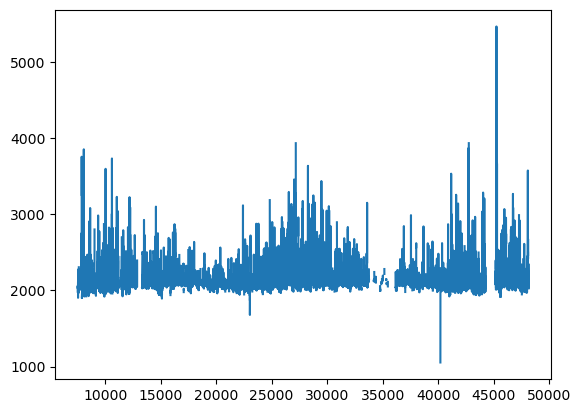

In [35]:
fluxtower['CH4'].plot()

It gives us a introductory sense of the data, but it isn't good for much else beyond that. Look at the x axis -- it's pretty hard to read the axis when it only shows the index number of the observation.

To improve this we can set the datetime column as the **index** of the dataframe.

In [72]:
fluxtower = fluxtower.set_index('TIMESTAMP_START')

<Axes: xlabel='TIMESTAMP_START'>

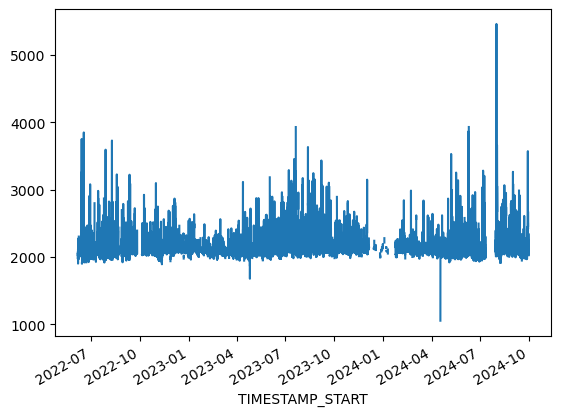

In [73]:
fluxtower['CH4'].plot()

Much prettier! But what else happened here? Because the index is now a datetime we can filter our rows based on the value of the index. For example, we could select just the rows that are from April 2024:

In [38]:
fluxtower.loc['2024-04']

,TIMESTAMP_END,CH4,CO2,FC,FCH4,H,H2O,MO_LENGTH,LE,NEE_PI,...,WTD_2_1_1,WTD_PI_1,P_1_1_1,TS_PI_1,SW_IN_1_1_1,SWC_PI_1,NETRAD_1_1_1,PPFD_IN_1_1_1,RH_1_1_1,HOUR
TIMESTAMP_START,,,,,,,,,,,,,,,,,,,,,
2024-04-01 00:00:00,2024-04-01 00:03:00,2108.81,398.007,1.63353,-0.559371,0.307182,12.7055,-76.91220,2.636220,NaN,...,NaN,NaN,0.0,13.838133,0.02380,69.462000,-48.3378,0.0331,99.9216,0
2024-04-01 00:03:00,2024-04-01 01:00:00,2102.48,327.227,-2.75409,-0.294715,0.487397,12.5017,-11.06080,-0.951638,NaN,...,NaN,NaN,0.0,13.756567,0.01460,69.473233,-49.3596,0.0318,99.9213,0
2024-04-01 01:00:00,2024-04-01 01:03:00,2107.51,NaN,NaN,3.846890,-0.813930,12.2420,1.78308,45.052700,NaN,...,NaN,NaN,0.0,13.745267,0.02910,69.521767,-49.5621,0.0583,99.9229,1
2024-04-01 01:03:00,2024-04-01 02:00:00,2111.53,NaN,NaN,1.712460,-0.351375,NaN,1.81799,NaN,NaN,...,NaN,NaN,0.0,13.707967,0.00993,69.556500,-48.5002,0.0543,99.9192,1
2024-04-01 02:00:00,2024-04-01 02:03:00,2112.83,NaN,NaN,0.907613,-0.292000,NaN,2.49570,NaN,NaN,...,NaN,NaN,0.0,13.666667,0.02580,69.562933,-48.3756,0.0331,99.9163,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-04-30 21:03:00,2024-04-30 22:00:00,2102.52,416.857,2.83834,91.020300,-9.741900,17.4378,15.39640,4.431730,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.9750,21
2024-04-30 22:00:00,2024-04-30 22:03:00,2138.06,416.853,7.65920,319.814000,-25.919600,17.4775,13.83080,10.920200,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.7523,22
2024-04-30 22:03:00,2024-04-30 23:00:00,2227.43,422.285,2.18512,32.818900,-6.781700,17.7636,21.53610,-2.685270,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68.8005,22


Or that are between April and June of 2024:

In [74]:
fluxtower.loc['2024-04':'2024-06']

,TIMESTAMP_END,CH4,CO2,FC,FCH4,H,H2O,MO_LENGTH,LE,NEE_PI,...,WTD_2_1_1,WTD_PI_1,P_1_1_1,TS_PI_1,SW_IN_1_1_1,SWC_PI_1,NETRAD_1_1_1,PPFD_IN_1_1_1,RH_1_1_1,HOUR
TIMESTAMP_START,,,,,,,,,,,,,,,,,,,,,
2024-04-01 00:00:00,2024-04-01 00:03:00,2108.81,398.007,1.63353,-0.559371,0.307182,12.705500,-76.91220,2.636220,NaN,...,NaN,NaN,0.0,13.838133,0.02380,69.462000,-48.3378,0.0331,99.921600,0
2024-04-01 00:03:00,2024-04-01 01:00:00,2102.48,327.227,-2.75409,-0.294715,0.487397,12.501700,-11.06080,-0.951638,NaN,...,NaN,NaN,0.0,13.756567,0.01460,69.473233,-49.3596,0.0318,99.921300,0
2024-04-01 01:00:00,2024-04-01 01:03:00,2107.51,NaN,NaN,3.846890,-0.813930,12.242000,1.78308,45.052700,NaN,...,NaN,NaN,0.0,13.745267,0.02910,69.521767,-49.5621,0.0583,99.922900,1
2024-04-01 01:03:00,2024-04-01 02:00:00,2111.53,NaN,NaN,1.712460,-0.351375,NaN,1.81799,NaN,NaN,...,NaN,NaN,0.0,13.707967,0.00993,69.556500,-48.5002,0.0543,99.919200,1
2024-04-01 02:00:00,2024-04-01 02:03:00,2112.83,NaN,NaN,0.907613,-0.292000,NaN,2.49570,NaN,NaN,...,NaN,NaN,0.0,13.666667,0.02580,69.562933,-48.3756,0.0331,99.916300,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-30 21:03:00,2024-06-30 22:00:00,2087.51,538.236,6.28854,225.262000,-15.898500,15.236500,49.49850,30.307400,NaN,...,NaN,NaN,0.0,26.966400,-0.00331,65.600000,-23.9861,0.0225,47.398100,21
2024-06-30 22:00:00,2024-06-30 22:03:00,NaN,511.231,8.76385,NaN,-6.314760,32.504000,61.65950,-35.848400,NaN,...,NaN,NaN,0.0,26.910267,-0.00530,65.572967,-23.5895,0.0755,98.673300,22
2024-06-30 22:03:00,2024-06-30 23:00:00,NaN,496.436,-29.15830,NaN,-7.415390,26.118000,70.75380,235.468000,NaN,...,NaN,NaN,0.5,26.866467,0.01190,65.533333,-19.5849,0.0278,76.991900,22


<Axes: xlabel='TIMESTAMP_START'>

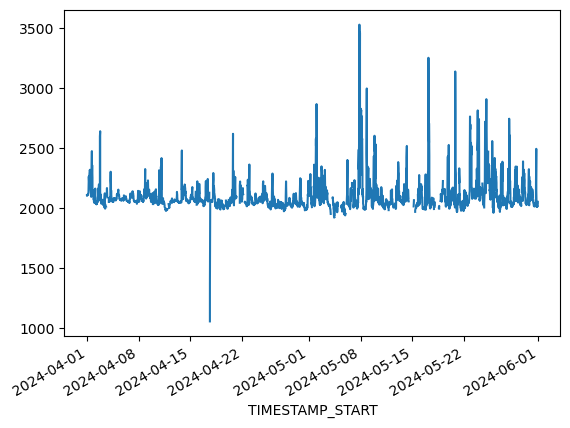

In [42]:
fluxtower.loc['2024-04':'2024-05']['CH4'].plot()

**Intermediate topics**
* `resample`